In [1]:
import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset
from tqdm import tqdm
import timm
from sklearn.kernel_approximation import Nystroem
from sklearn.linear_model import SGDOneClassSVM
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
import numpy as np
from sympy.tensor import tensor
from torch.utils.data import random_split, TensorDataset
import sys
import os

In [2]:
"""
Create synthetic "anomalies" 
Returns: The same `hists` tensor, modified in place, with synthetic
anomalies added.
"""
def shift_x_and_add5(hists, plus=1,precent=1):
  for i in range(len(hists)):
    if i%100==0:
      print("in",i)
    hist=hists[i,0]
    cols = torch.where(torch.any(hists[i,0] != 0, axis=0))[0]
    first_from_end = cols[-1]+1
    width = max(int(precent * first_from_end) + 1, 1)
    pad_amt = max(214 - width, 0)
    hist_cp_part = np.pad(np.copy(hists[i, 0, :, :width]),((0, 0), (0, pad_amt)),mode='constant',constant_values=0)
    shifted = np.zeros_like(hist)
    for j in range(plus):
      shift = np.random.randint(10, 105)
      shifted =shifted+ np.roll(hist_cp_part, shift=shift, axis=1)
    hists[i,0]=hist+shifted
  return hists

In [3]:
"""
Run a batch of images through a pretrained model to extract
deep feature embeddings.
Returns:
A NumPy array of shape (N, feature_dim) containing the extracted
feature vector for each input sample.
"""
def feture_extract(m, X, batch=32):
    if torch.cuda.is_available():
        device = torch.device("cuda")
    else:
        device = torch.device("cpu")

    m = m.to(device)

    m.eval()
    m=m.encode
    loader = DataLoader(
        TensorDataset(X),
        batch_size=batch,
        shuffle=False,
    )

    features = []

    with torch.no_grad():
        for (x,) in tqdm(loader, desc="Extracting features"):
            x = x.to(device)
            features.append(m(x))

    # Move concatenated output back to CPU before converting to NumPy
    return torch.cat(features, dim=0).cpu().numpy()

In [4]:
class Autoencoder4(nn.Module):
    def __init__(self):
        super(Autoencoder4, self).__init__()
        self.encoder = nn.Sequential(
            nn.Conv2d(1, 10, 5, stride=2, padding=1),
            #nn.BatchNorm2d(10),
            nn.LeakyReLU(0.01),

            nn.Conv2d(10, 10, 5, stride=2, padding=1),
            nn.LeakyReLU(0.01),
            nn.Dropout2d(0.25),
            nn.Conv2d(10, 20, 5, stride=2, padding=1),
            nn.LeakyReLU(0.01),

            nn.Conv2d(20, 20, 5, stride=2, padding=1),
            nn.LeakyReLU(0.01),
            nn.Dropout2d(0.25),
            nn.Flatten(),
            nn.LazyLinear(2000),
            nn.LeakyReLU(0.01),
            nn.Dropout(0.25),
            nn.LazyLinear(500),

        )
        self.decoder = nn.Sequential(
            nn.Linear(500, 2000),
            nn.LeakyReLU(0.01),
            nn.Linear(2000, 20 * 13 * 13),
            #nn.BatchNorm1d(20 * 13 * 13),
            nn.LeakyReLU(0.01),
            nn.Unflatten(1, (20, 13, 13)),               # -> 20 x 13 x 13
            nn.Upsample(size=27, mode='bilinear', align_corners=False),        # 13 -> 27
            nn.Conv2d(20, 10, 3, stride=1, padding=1),
            #nn.BatchNorm2d(10),
            nn.LeakyReLU(0.01),
            nn.Upsample(size=53, mode='bilinear', align_corners=False),        # 27 -> 53
            nn.Conv2d(10, 10, 3, stride=1, padding=1),
            #nn.BatchNorm2d(10),
            nn.LeakyReLU(0.01),
            nn.Upsample(size=107, mode='bilinear', align_corners=False),       # 53 -> 107
            nn.Conv2d(10, 10, 3, stride=1, padding=1),
            #n.BatchNorm2d(10),
            nn.LeakyReLU(0.01),
            nn.Upsample(size=214, mode='bilinear', align_corners=False),       # 107 -> 214
            nn.Conv2d(10, 1, 3, stride=1, padding=1),
            #nn.BatchNorm2d(1),
            nn.Hardtanh(min_val=0.0, max_val=1.0)
        )

    def forward(self, x):
        x = self.encoder(x)
        x = self.decoder(x)
        return x
    def encode(self, x):
        return self.encoder(x)

In [5]:

m = Autoencoder4() # Must initialize first
m.load_state_dict(torch.load('/kaggle/input/models/nachmanrog/auto4/pytorch/default/1/best_model_aoutoencoder4.pt', weights_only=True,map_location=torch.device("cuda" if torch.cuda.is_available() else "cpu")))


<All keys matched successfully>

In [6]:
# "bot" data: treated as the "normal" class the One-Class SVM will learn.
path_all_bot=r"/kaggle/input/datasets/nachmanrog/yt-bot/yt_all.npy"
#"human/agent" data: the population we want to inspect after
path_all_human_or_agent=r"/kaggle/input/datasets/nachmanrog/yt-human/yt_human_all.npy"

m.eval()

data=np.load(path_all_bot)# "bot" data: treated as the "normal" class the One-Class SVM will learn.
print("number of FlowPics in train data from bot browsing: ",len(data))
rng = np.random.default_rng()
rng.shuffle(data)
data_h_a=np.load(path_all_human_or_agent)#"human/agent" data: the population we want to inspect after
print("number of FlowPics in data from human/agent browsing: ",len(data_h_a))


# Train/test split of the "bot" (normal) data
train_size = int(0.9 * len(data))
test_size = int( len(data))-train_size

# 3. Perform the split (Optional: pass a Generator for reproducibility)
generator = torch.Generator()
train_set, test_set = random_split(
    data,
    [train_size, test_size],
    generator=generator
)


number of FlowPics in train data from bot browsing:  11277
number of FlowPics in data from human/agent browsing:  725


In [7]:
# Convert to float tensors and add a channel dimension (N, 1, H, W) 
X_train = torch.from_numpy(np.copy(train_set)).unsqueeze(1).float()
X_test = torch.from_numpy(np.copy(test_set)).unsqueeze(1).float()
# Build a synthetic "anomaly" version of the test set by shifting/adding
X_test_mod =shift_x_and_add5( torch.from_numpy(np.copy(test_set)).unsqueeze(1).float(),plus=2,precent=1)
X_h_a=torch.from_numpy(np.copy(data_h_a)).unsqueeze(1).float()

#Normalization 
# log1p compresses
X_train = torch.log1p(X_train)
X_test = torch.log1p(X_test)
X_test_mod= torch.log1p(X_test_mod)
X_h_a= torch.log1p(X_h_a)
# Normalize all four datasets by a single shared maximum value
max_val=max(X_train.max(),X_test.max(),X_test_mod.max(),X_h_a.max())
X_train=X_train/max_val
X_test=X_test/max_val
X_test_mod=X_test_mod/max_val
X_h_a=X_h_a/max_val



in 0
in 100
in 200


/tmp/ipykernel_136/164589943.py:20: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  hists[i,0]=hist+shifted


in 300
in 400
in 500
in 600
in 700
in 800
in 900
in 1000
in 1100


In [8]:
# Feature extraction via the pretrained model
X_train_feture=feture_extract(m,X_train)
X_test_feture=feture_extract(m,X_test)
X_test_mod_feture=feture_extract(m,X_test_mod)
X_h_a_feture=feture_extract(m,X_h_a)
print(X_train_feture.shape,X_test_feture.shape,X_test_mod_feture.shape,X_h_a_feture.shape)


Extracting features: 100%|██████████| 23/23 [00:00<00:00, 307.37it/s]

(10149, 500) (1128, 500) (1128, 500) (725, 500)


In [9]:
# Standardize features (zero mean, unit variance)
scaler = StandardScaler()
# Fit scaler on all datasets
all_data = np.concatenate(
    [X_train_feture, X_test_feture, X_test_mod_feture,X_h_a_feture],
    axis=0
)
print(all_data.shape)
scaler.fit(all_data)
X_train_feture_norm=scaler.transform(X_train_feture)
X_test_feture_norm=scaler.transform(X_test_feture)
X_test_mod_feture_norm=scaler.transform(X_test_mod_feture)
X_h_a_feture_norm=scaler.transform(X_h_a_feture)


(13130, 500)


In [10]:
#PCA dimensionality + One-Class SVM 
import itertools
import numpy as np
import pandas as pd
from sklearn.metrics import f1_score, precision_score, recall_score, roc_auc_score
from sklearn.svm import OneClassSVM
from sklearn.decomposition import PCA
results = []



# build combined eval set with ground truth labels
X_eval = np.vstack([X_test_feture_norm, X_test_mod_feture_norm])
y_eval = np.concatenate([
    np.ones(len(X_test_feture_norm)),        # normal = 1
    -np.ones(len(X_test_mod_feture_norm))    # anomaly = -1
])

nu_grid = [ 0.01, 0.05, 0.1]
gamma_grid = [ 'scale']



# One-Class SVM on diffrent set of nu with gamma=scale 

for nu, gamma in itertools.product(nu_grid, gamma_grid):
    print(f" nu: {nu}, gamma: {gamma} ")
    clf = OneClassSVM( gamma=gamma,kernel="rbf", nu=nu)#
    clf.fit(X_train_feture_norm)


    y_pred = clf.predict(X_eval)          # -1 / 1
    scores = clf.decision_function(X_eval)  # higher = more "normal"

    f1 = f1_score(y_eval, y_pred, pos_label=1)          # normal = positive class
    precision = precision_score(y_eval, y_pred, pos_label=1, zero_division=0)
    recall = recall_score(y_eval, y_pred, pos_label=1, zero_division=0)
    auc = roc_auc_score((y_eval == 1).astype(int), scores)  # 1=normal for AUC convention

    # also track how well it does on train (shouldn't over-flag normal training data)
    y_pred_train = clf.predict(X_train_feture_norm)
    train_normal_acc = (y_pred_train == 1).mean()

    results.append({
        'nu': nu, 'gamma': gamma,
        'f1': f1, 'precision': precision, 'recall': recall, 'auc': auc,
        'train_normal_acc': train_normal_acc
    })

results_df = pd.DataFrame(results).sort_values('f1', ascending=False)
print(results_df.head(15))

 nu: 0.01, gamma: scale 
 nu: 0.05, gamma: scale 
 nu: 0.1, gamma: scale 
     nu  gamma        f1  precision    recall       auc  train_normal_acc
1  0.05  scale  0.701926   0.555556  0.953014  0.580843          0.949847
0  0.01  scale  0.700220   0.542662  0.986702  0.550041          0.988570
2  0.10  scale  0.692935   0.561674  0.904255  0.600998          0.900680


In [11]:
results_df = pd.DataFrame(results).sort_values('f1', ascending=False)
print(results_df.head(15))

     nu  gamma        f1  precision    recall       auc  train_normal_acc
1  0.05  scale  0.701926   0.555556  0.953014  0.580843          0.949847
0  0.01  scale  0.700220   0.542662  0.986702  0.550041          0.988570
2  0.10  scale  0.692935   0.561674  0.904255  0.600998          0.900680


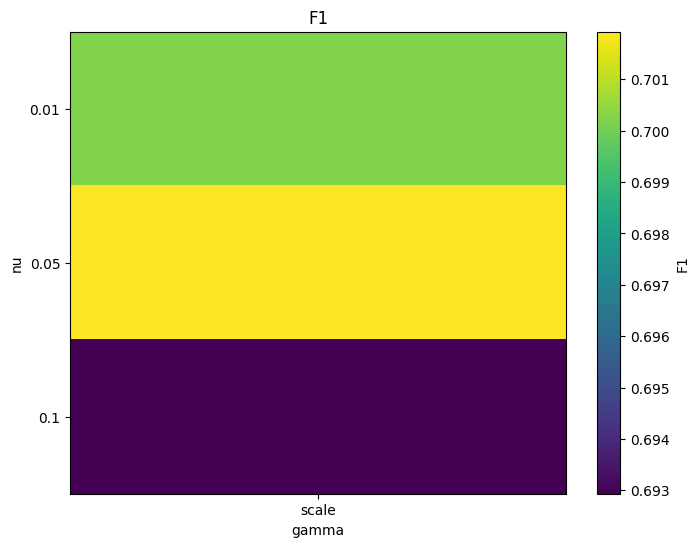

In [12]:
# Visualize the hyperparameter sweep as heatmaps (F1 score vs nu/gamma)
import matplotlib.pyplot as plt
pivot = results_df.pivot_table(
    index='nu',
    columns='gamma',
    values='f1'
)

fig, ax = plt.subplots(figsize=(8, 6))

im = ax.imshow(
    pivot.values,
    aspect='auto',
    cmap='viridis'
)

ax.set_xticks(range(len(pivot.columns)))
ax.set_xticklabels(pivot.columns)

ax.set_yticks(range(len(pivot.index)))
ax.set_yticklabels(pivot.index)

ax.set_xlabel('gamma')
ax.set_ylabel('nu')
ax.set_title('F1')

fig.colorbar(im, ax=ax, label='F1')


In [13]:
from sklearn.svm import OneClassSVM
#best prameters from last part by F1
nu = 0.05
gamma = 'scale'

# Fit the One-Class SVM
clf = OneClassSVM(gamma=gamma, kernel="rbf", nu=nu)
clf.fit(X_train_feture_norm)

OneClassSVM(nu=0.05)

In [14]:

y_pred_human_or_agent = clf.predict(X_h_a_feture_norm)

not_same = y_pred_human_or_agent[y_pred_human_or_agent == -1].size
print("not_same=",not_same)
same = y_pred_human_or_agent[y_pred_human_or_agent == 1].size
print("same=",same)
# Fraction of human/agent samples classified as "normal"
print(" Fraction of human/agent samples classified as normal=",(same/len(y_pred_human_or_agent)))

not_same= 123
same= 602
 Fraction of human/agent samples classified as normal= 0.8303448275862069


In [15]:
# Split the human/agent samples into those flagged as anomalous vs normal,
# for visual inspection below.
X_h_a_anomaly=data_h_a[y_pred_human_or_agent==-1]
X_h_a_normal=data_h_a[y_pred_human_or_agent==1]

In [16]:
"""
Save a random sample of 2D histogram images as individual PNGs, then
stitch them together into a single mosaic image for quick visual
review.
"""

def carate_pics(data,output_dir,size=60,num_cols = 4):
  from PIL import Image
  import math
  x = np.zeros(len(data), dtype=int)
  x[:size] = 1
  np.random.shuffle(x)
  data=data[x==1,:,:]
  print(data.shape)
  os.makedirs(output_dir, exist_ok=True)
  for i, histogram in enumerate(data):
      print(histogram.shape,i)
      fig, ax = plt.subplots(figsize=(8, 6))
      im = ax.imshow(histogram, cmap="grey_r",vmax=1,extent=[0, 1500, 0, 1500])
      #fig.colorbar(im, ax=ax, label="Value")
      fig.tight_layout()
      fig.savefig(
          os.path.join(output_dir, f"image_{i:05d}.png"),
          dpi=150
      )
      plt.close(fig)

  # Create mosaic
  image_files = sorted([
      os.path.join(output_dir, f)
      for f in os.listdir(output_dir)
      if f.endswith(".png") and f.startswith("image_")
  ])
  images = [Image.open(f) for f in image_files]
  n_cols = num_cols
  n_rows = math.ceil(len(images) / n_cols)
  img_width, img_height = images[0].size
  mosaic = Image.new(
      "RGB",
      (n_cols * img_width, n_rows * img_height),
      "white"
  )
  for i, img in enumerate(images):
      row = i // n_cols
      col = i % n_cols
      x = col * img_width
      y = row * img_height
      mosaic.paste(img, (x, y))
  mosaic_path = os.path.join(output_dir, "mosaic.png")
  mosaic.save(mosaic_path)
  print("Mosaic saved to:", mosaic_path)

In [17]:
# Human/agent samples the model flagged as "anomalous" (different from bot
# data) and "normal" (similar to bot data), respectively.
carate_pics(X_h_a_anomaly,r"/kaggle/working/anomaly")
carate_pics(X_h_a_normal,r"/kaggle/working/normal")
# A sample of the original bot training data itself, for visual reference.
carate_pics(data,r"/kaggle/working/bot",size=100)

(60, 214, 214)
(214, 214) 0
(214, 214) 1
(214, 214) 2
(214, 214) 3
(214, 214) 4
(214, 214) 5
(214, 214) 6
(214, 214) 7
(214, 214) 8
(214, 214) 9
(214, 214) 10
(214, 214) 11
(214, 214) 12
(214, 214) 13
(214, 214) 14
(214, 214) 15
(214, 214) 16
(214, 214) 17
(214, 214) 18
(214, 214) 19
(214, 214) 20
(214, 214) 21
(214, 214) 22
(214, 214) 23
(214, 214) 24
(214, 214) 25
(214, 214) 26
(214, 214) 27
(214, 214) 28
(214, 214) 29
(214, 214) 30
(214, 214) 31
(214, 214) 32
(214, 214) 33
(214, 214) 34
(214, 214) 35
(214, 214) 36
(214, 214) 37
(214, 214) 38
(214, 214) 39
(214, 214) 40
(214, 214) 41
(214, 214) 42
(214, 214) 43
(214, 214) 44
(214, 214) 45
(214, 214) 46
(214, 214) 47
(214, 214) 48
(214, 214) 49
(214, 214) 50
(214, 214) 51
(214, 214) 52
(214, 214) 53
(214, 214) 54
(214, 214) 55
(214, 214) 56
(214, 214) 57
(214, 214) 58
(214, 214) 59
Mosaic saved to: /kaggle/working/anomaly/mosaic.png
(60, 214, 214)
(214, 214) 0
(214, 214) 1
(214, 214) 2
(214, 214) 3
(214, 214) 4
(214, 214) 5
(214, 214)